In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 5)


In [2]:
CSV_PATH = "../prices/CL.csv"  # <-- set this
DATE_COL = "Date"

df = pd.read_csv(CSV_PATH)

df[DATE_COL] = pd.to_datetime(df[DATE_COL], format="%d %b %Y", errors="coerce")
df = df.dropna(subset=[DATE_COL]).sort_values(DATE_COL).set_index(DATE_COL)

for c in ["Open", "High", "Low", "Close", "Volume", "OpenInterest"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["Open", "High", "Low", "Close"]).copy()
df.tail()


,Open,High,Low,Close,Volume,OpenInterest
Date,,,,,,
2026-01-26,61.22,61.71,60.32,60.63,-0.44,0.0
2026-01-27,60.78,62.63,60.14,62.39,1.76,0.0
2026-01-28,62.58,63.57,62.07,63.21,0.82,0.0
2026-01-29,63.50,66.48,63.28,65.42,2.21,0.0
2026-01-30,65.53,66.10,63.65,65.21,-0.21,0.0


In [3]:
def atr(high, low, close, n=20):
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low).abs(),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(n).mean()

def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def donchian_channels(high, low, n):
    upper = high.rolling(n).max()
    lower = low.rolling(n).min()
    return upper, lower


In [4]:
def backtest_futures_trend_long_short(
    df,
    *,
    breakout_n=55,
    exit_n=20,
    atr_n=20,
    ema_span=200,
    use_ema_filter=True,
    target_annual_vol=0.20,
    max_leverage=2.0,
    cost_bps=2.0,
    slippage_bps=1.0,
    periods_per_year=252,
):
    px = df.copy()

    # Indicators
    px["ATR"] = atr(px["High"], px["Low"], px["Close"], n=atr_n)
    px["ATR_PCT"] = px["ATR"] / px["Close"]
    px["EMA"] = ema(px["Close"], span=ema_span)

    up, dn = donchian_channels(px["High"], px["Low"], n=breakout_n)
    px["DONCH_UP"] = up
    px["DONCH_DN"] = dn

    exit_up, exit_dn = donchian_channels(px["High"], px["Low"], n=exit_n)
    px["EXIT_UP"] = exit_up
    px["EXIT_DN"] = exit_dn

    # Breakout signals at close; trade next open
    long_entry  = px["Close"] > px["DONCH_UP"].shift(1)
    short_entry = px["Close"] < px["DONCH_DN"].shift(1)

    long_exit  = px["Close"] < px["EXIT_DN"].shift(1)
    short_exit = px["Close"] > px["EXIT_UP"].shift(1)

    if use_ema_filter:
        long_ok  = px["Close"] > px["EMA"]
        short_ok = px["Close"] < px["EMA"]
    else:
        long_ok  = pd.Series(True, index=px.index)
        short_ok = pd.Series(True, index=px.index)

    # Position state machine: -1, 0, +1
    pos = pd.Series(0.0, index=px.index)
    state = 0  # -1 short, 0 flat, +1 long

    for i in range(len(px.index)):
        if i == 0:
            pos.iloc[i] = 0.0
            continue

        if state == 0:
            # Entries (if both trigger, ignore / stay flat; rare but possible)
            le = bool(long_entry.iloc[i] and long_ok.iloc[i])
            se = bool(short_entry.iloc[i] and short_ok.iloc[i])

            if le and not se:
                state = 1
            elif se and not le:
                state = -1

        elif state == 1:
            # Long exits; optional flip-to-short if breakout occurs
            if bool(long_exit.iloc[i]) or (use_ema_filter and not bool(long_ok.iloc[i])):
                state = 0
            else:
                # allow reversal on strong opposite breakout
                if bool(short_entry.iloc[i] and short_ok.iloc[i]):
                    state = -1

        elif state == -1:
            # Short exits; optional flip-to-long if breakout occurs
            if bool(short_exit.iloc[i]) or (use_ema_filter and not bool(short_ok.iloc[i])):
                state = 0
            else:
                if bool(long_entry.iloc[i] and long_ok.iloc[i]):
                    state = 1

        pos.iloc[i] = float(state)

    # Vol targeting
    target_daily_vol = target_annual_vol / np.sqrt(periods_per_year)
    est_daily_vol = px["ATR_PCT"].replace(0, np.nan)

    lev = (target_daily_vol / est_daily_vol).clip(upper=max_leverage).fillna(0.0)

    # Execute at next open
    pos_exec = pos.shift(1).fillna(0.0)
    lev_exec = lev.shift(1).fillna(0.0)
    exposure = pos_exec * lev_exec  # signed exposure

    # Open-to-Open returns (consistent with open execution)
    r = px["Open"].pct_change().fillna(0.0)

    # Turnover cost on exposure changes
    turnover = exposure.diff().abs().fillna(0.0)
    total_bps = cost_bps + slippage_bps
    costs = turnover * (total_bps / 1e4)

    strat_ret = exposure * r - costs

    out = pd.DataFrame(index=px.index)
    out["ret"] = strat_ret
    out["pos"] = pos
    out["lev"] = lev
    out["exposure"] = exposure
    out["turnover"] = turnover
    out["costs"] = costs
    out["equity"] = (1 + out["ret"]).cumprod()

    # Benchmark: buy&hold open-open (unlevered)
    out["bh_ret"] = r
    out["bh_equity"] = (1 + out["bh_ret"]).cumprod()

    # Diagnostics
    out["Close"] = px["Close"]
    out["EMA"] = px["EMA"]
    out["DONCH_UP"] = px["DONCH_UP"]
    out["DONCH_DN"] = px["DONCH_DN"]
    out["EXIT_UP"] = px["EXIT_UP"]
    out["EXIT_DN"] = px["EXIT_DN"]
    out["ATR_PCT"] = px["ATR_PCT"]

    return out


In [5]:
def max_drawdown(equity: pd.Series) -> float:
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min())

def cagr(equity: pd.Series, periods_per_year=252) -> float:
    n = len(equity)
    if n <= 1:
        return np.nan
    years = n / periods_per_year
    return float(equity.iloc[-1] ** (1/years) - 1)

def sharpe(returns: pd.Series, periods_per_year=252) -> float:
    mu = returns.mean()
    sig = returns.std(ddof=0)
    if sig == 0:
        return np.nan
    return float((mu / sig) * np.sqrt(periods_per_year))

def summary_stats(bt: pd.DataFrame, periods_per_year=252) -> pd.Series:
    rets = bt["ret"]
    eq = bt["equity"]
    stats = {
        "CAGR": cagr(eq, periods_per_year),
        "Sharpe": sharpe(rets, periods_per_year),
        "MaxDD": max_drawdown(eq),
        "Vol(ann)": float(rets.std(ddof=0) * np.sqrt(periods_per_year)),
        "PctTimeLong": float((bt["exposure"] > 0).mean()),
        "PctTimeShort": float((bt["exposure"] < 0).mean()),
        "PctTimeFlat": float((bt["exposure"] == 0).mean()),
        "AvgAbsExposure": float(bt["exposure"].abs().mean()),
        "AvgTurnover": float(bt["turnover"].mean()),
        "TotalCosts(%)": float(bt["costs"].sum() * 100),
    }
    return pd.Series(stats)


In [16]:
df = df[df.index >= "2018-01-01"]

In [17]:
bt = backtest_futures_trend_long_short(
    df,
    breakout_n=20,
    exit_n=10,
    atr_n=20,
    ema_span=100,
    use_ema_filter=True,
    target_annual_vol=0.20,
    max_leverage=2.0,
    cost_bps=2.0,
    slippage_bps=1.0,
)

display(summary_stats(bt))


CAGR              0.181312
Sharpe            1.697144
MaxDD            -0.048980
Vol(ann)          0.101213
PctTimeLong       0.289439
PctTimeShort      0.261408
PctTimeFlat       0.449153
AvgAbsExposure    0.213762
AvgTurnover       0.028398
TotalCosts(%)     1.306858
dtype: float64

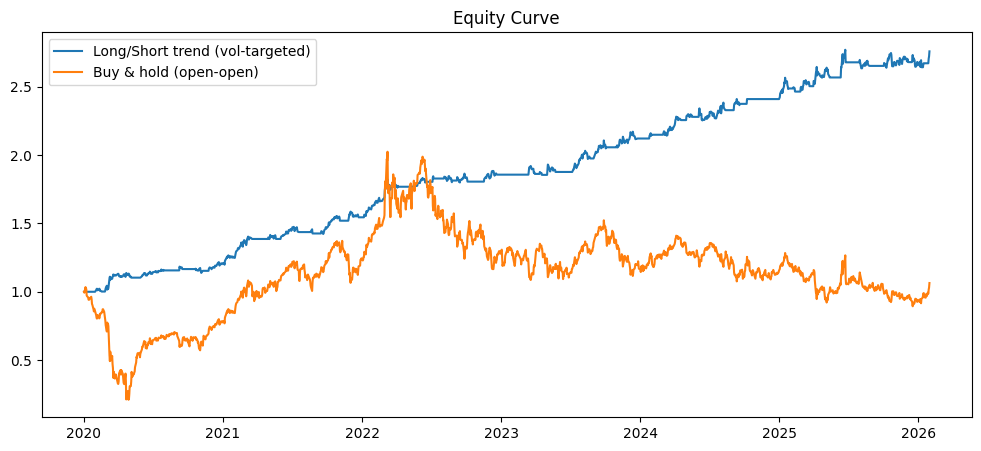

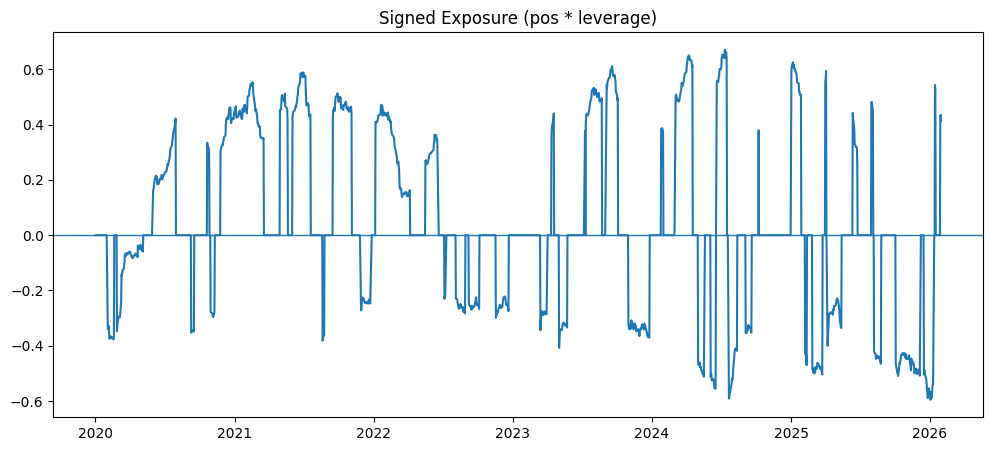

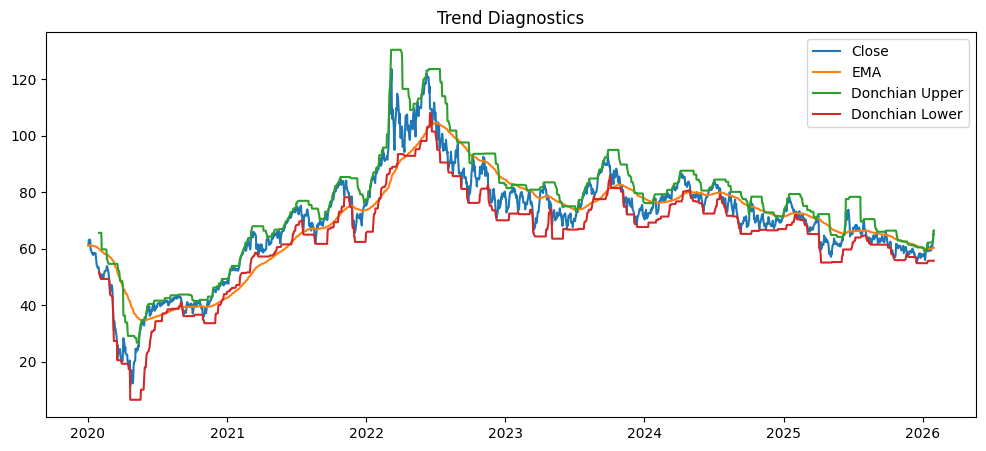

In [18]:
# Equity curve
plt.figure()
plt.plot(bt.index, bt["equity"], label="Long/Short trend (vol-targeted)")
plt.plot(bt.index, bt["bh_equity"], label="Buy & hold (open-open)")
plt.title("Equity Curve")
plt.legend()
plt.show()

# Exposure (signed)
plt.figure()
plt.plot(bt.index, bt["exposure"])
plt.axhline(0, linewidth=1)
plt.title("Signed Exposure (pos * leverage)")
plt.show()

# Price + channels
plt.figure()
plt.plot(bt.index, bt["Close"], label="Close")
plt.plot(bt.index, bt["EMA"], label="EMA")
plt.plot(bt.index, bt["DONCH_UP"], label="Donchian Upper")
plt.plot(bt.index, bt["DONCH_DN"], label="Donchian Lower")
plt.title("Trend Diagnostics")
plt.legend()
plt.show()


In [19]:
bt["equity"].to_csv('../../portfolio/data/trend-long-short-futures-oil.csv')